# LangGraph Lab: Minimal MessagesState Agent

A minimal showcase of a LangGraph tool-calling agent with explicit graph construction.

**Core concepts:**
- `MessagesState` — message-based state with reducer support
- Tool definitions via `@tool` decorator
- `StateGraph` + `builder.add_node(...)` — explicit control flow
- Private mood state inferred from human messages
- Single dataclass, two tools, graph visualization

## Setup

In [1]:
import nest_asyncio
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic

# Enable async execution in Jupyter
nest_asyncio.apply()

# Load environment variables (ANTHROPIC_API_KEY, etc.)
load_dotenv()

# --- Initialize LLM ---
# Using Claude Haiku for speed and cost-efficiency in the lab.
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)

## Mock Data

In [2]:
from dataclasses import dataclass


# --- Single Dataclass ---
@dataclass
class Article:
    """A lightweight article representation for Inkwell.

    Attributes:
        slug: URL-safe unique identifier (e.g., 'react-intro')
        title: Human-readable article title
        content: Full markdown content
        tags: List of keyword tags for categorization
    """

    slug: str
    title: str
    content: str
    tags: list[str]


# --- Mock Article Store ---
# In production, this would be fetched from GitHub via the REST API.
# For this lab, we use in-memory mock data for safe experimentation.
ARTICLES = {
    "react-intro": Article(
        slug="react-intro",
        title="Introduction to ReAct",
        content=(
            "ReAct stands for Reasoning + Acting. The agent loops:\n"
            "1. Observe the current state\n"
            "2. Reason about what to do next\n"
            "3. Act by calling a tool\n"
            "4. Return to step 1 with the tool result\n"
            "This creates a multi-step problem-solving flow."
        ),
        tags=["agents", "llm"],
    ),
    "state-guide": Article(
        slug="state-guide",
        title="State Management in Graphs",
        content=(
            "Graph state is the core data structure flowing through your agent.\n"
            "Define it with TypedDict or Pydantic to shape agent behavior.\n"
            "The state schema is the contract between graph nodes."
        ),
        tags=["langgraph", "state"],
    ),
    "tools-101": Article(
        slug="tools-101",
        title="Tool Calling in LangGraph",
        content=(
            "Agents call tools to interact with external systems.\n"
            "Tools are registered as LangChain @tool decorated functions.\n"
            "The docstring becomes the schema the LLM sees."
        ),
        tags=["langgraph", "tools"],
    ),
}

print(f"✓ Mock article store loaded with {len(ARTICLES)} articles")
print(f"  Slugs: {', '.join(ARTICLES.keys())}")

✓ Mock article store loaded with 3 articles
  Slugs: react-intro, state-guide, tools-101


## Tool Definitions

In [3]:
from langchain_core.tools import tool


# @tool decorator wraps your function as a structured tool with a name and description.
# It reads your function signature and docstring to build a schema for arguments, so the model knows what inputs are required
# When a tool call happens, inputs are validated/coerced before your function runs
@tool
def list_articles() -> str:
    """List all articles in the user's Inkwell library.

    Returns a formatted table with slug, title, and tags.
    Use this to see what articles exist.
    """
    print("✓ list_articles called")

    if not ARTICLES:
        return "No articles found."

    # Format as simple table for readability
    lines = ["slug | title | content | tags", "--- | --- | --- | ---"]
    for a in ARTICLES.values():
        tags_str = ", ".join(a.tags) if a.tags else "(none)"
        lines.append(f"{a.slug} | {a.title} | {a.content} | {tags_str}")

    return "\n".join(lines)


@tool
def save_article(slug: str, content: str) -> str:
    """Update an article's content.

    Args:
        slug: The article slug to update.
        content: The new markdown content.

    Returns:
        Confirmation message with the slug.
    """
    print(f"✓ save_article called with slug='{slug}' and content length={len(content)}")

    if slug not in ARTICLES:
        return f"Article not found: {slug}"

    # Update the article in memory
    ARTICLES[slug].content = content

    return f"✓ Saved: {slug}"


chat_llm = llm.bind_tools([list_articles, save_article])

## Graph Construction

✓ Agent graph created with write-step approval breakpoint (interrupt_before=save_article).

Graph visualization (Mermaid diagram):


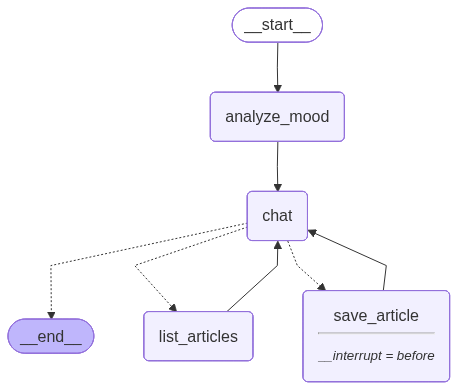

In [4]:
from typing import Annotated, Literal

from IPython.display import Image, display
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

MoodLabel = Literal["neutral", "curious", "frustrated", "excited"]


class PublicMessagesState(TypedDict):
    # This makes the reducer explicit in the demo: message updates are merged with
    # LangGraph's built-in add_messages reducer instead of overwriting the list.
    # MessagesState is the built-in shortcut for this same structure.
    messages: Annotated[list[AnyMessage], add_messages]


class PrivateMoodState(TypedDict):
    # This is the private channel written by analyze_mood.
    # It exists to show the exact state fragment that node returns, and it is not part
    # of the public graph input/output contract.
    mood: MoodLabel


class AgentState(PublicMessagesState, PrivateMoodState):
    # This is the internal graph state consumed by chat after analyze_mood runs.
    # It combines the public messages state with the private mood key, so the chat node's
    # input type makes it clear that both messages and inferred mood are available there.
    pass


class MoodAnalysis(BaseModel):
    """Structured mood signal inferred from the user's human messages."""

    mood: MoodLabel = Field(
        description="Overall user mood inferred from all human messages in the thread."
    )
    rationale: str = Field(description="Short explanation describing why that mood was selected.")


mood_llm = llm.with_structured_output(MoodAnalysis)


def _human_message_text(state: PublicMessagesState) -> str:
    """Collect all human messages into a compact transcript for mood analysis."""
    lines = []
    for message in state["messages"]:
        if isinstance(message, HumanMessage):
            content = message.content if isinstance(message.content, str) else str(message.content)
            lines.append(f"- {content}")
    return "\n".join(lines) or "- (no human messages yet)"


async def analyze_mood(state: PublicMessagesState) -> PrivateMoodState:
    """Infer mood from all human messages and store it in private state."""
    transcript = _human_message_text(state)
    analysis = await mood_llm.ainvoke(
        [
            SystemMessage(
                content=(
                    "You analyze the user's mood across the full conversation. "
                    "Choose exactly one mood from: neutral, curious, frustrated, excited."
                )
            ),
            HumanMessage(
                content=(
                    "Infer the user's current overall mood from all human messages below. "
                    "Base the answer on the full transcript, not just the last turn.\n\n"
                    f"{transcript}"
                )
            ),
        ]
    )
    print(f"✓ analyze_mood inferred mood='{analysis.mood}' ({analysis.rationale})")
    return {"mood": analysis.mood}


async def chat(state: AgentState) -> dict:
    """Run the tool-bound model with tone conditioned on the inferred private mood."""
    mood = state.get("mood", "neutral")
    system_message = SystemMessage(
        content=(
            "You are a concise writing-assistant for Inkwell. "
            f"The user's inferred mood is '{mood}'. "
            "Adapt your response style to that mood while staying useful and accurate. "
            "If frustrated, be extra direct, calm, and reassuring. "
            "If curious, be explanatory and exploratory. "
            "If excited, match the energy while staying concrete. "
            "If neutral, respond in a straightforward professional tone."
        )
    )
    response = await chat_llm.ainvoke([system_message, *state["messages"]])
    return {"messages": [response]}


def route_tools_by_name(state: AgentState) -> str:
    """Route the next step to a dedicated tool node based on requested tool names."""
    if not state.get("messages"):
        return END

    last_message = state["messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None) or []
    if not tool_calls:
        return END

    write_tool_names = {"save_article"}
    called_tools = {call.get("name") for call in tool_calls if isinstance(call, dict)}

    if called_tools & write_tool_names:
        return "save_article"

    return "list_articles"


builder = StateGraph(
    AgentState,
    input_schema=PublicMessagesState,
    output_schema=PublicMessagesState,
)
builder.add_node("analyze_mood", analyze_mood)
builder.add_node("chat", chat)
builder.add_node("list_articles", ToolNode([list_articles]))
builder.add_node("save_article", ToolNode([save_article]))
builder.add_edge(START, "analyze_mood")
builder.add_edge("analyze_mood", "chat")
builder.add_conditional_edges(
    "chat",
    route_tools_by_name,
    {
        "list_articles": "list_articles",
        "save_article": "save_article",
        END: END,
    },
)
# Loop each tool branch back to chat so it can reason on tool results before ending.
# The private mood channel remains in internal graph state but is omitted from graph output.
builder.add_edge("list_articles", "chat")
builder.add_edge("save_article", "chat")

# Required for pause/resume when using interrupt_before in human-in-the-loop flows.
memory = InMemorySaver()
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=["save_article"],
)

print("✓ Agent graph created with write-step approval breakpoint (interrupt_before=save_article).")
print("\nGraph visualization (Mermaid diagram):")
display(Image(graph.get_graph().draw_mermaid_png()))

## Multi-Turn Demo

Uses one persistent `thread_id` plus the graph checkpointer, so we only send the new user message each turn (no manual `history` list).
Write actions still pause at `interrupt_before=["write_tools"]` for approval.

In [5]:
from uuid import uuid4

from langchain_core.messages import AIMessage, ToolMessage


def _print_stream_message(message):
    """Pretty-print one streamed message chunk by role/type."""
    if isinstance(message, HumanMessage):
        print(f"Human: {message.content}")
    elif isinstance(message, AIMessage):
        print(f"AI: {message.content}")
        if getattr(message, "tool_calls", None):
            print(f"  Tool calls: {message.tool_calls}")
    elif isinstance(message, ToolMessage):
        print(f"Tool ({message.name}): {message.content}")
    else:
        print(f"{type(message).__name__}: {message}")


async def run_stream_turn(
    turn_title: str,
    user_text: str,
    thread: dict,
    require_write_approval: bool = True,
):
    """Run one turn and optionally require approval before executing write tools."""
    print("\n" + "=" * 70)
    print(turn_title)
    print("=" * 70)

    latest_messages = []
    seen = 0
    write_executed = True

    # stream_mode="values" yields the full state snapshot after each graph step.
    # Other useful modes:
    # - "updates": emit only per-node state deltas.
    # - "messages": stream token/message chunks from chat model calls.
    # - "custom": stream user-defined events from inside nodes/tools.
    # - "debug": stream verbose execution diagnostics.
    async for event in graph.astream(
        {"messages": [HumanMessage(content=user_text)]},
        config=thread,
        stream_mode="values",
    ):
        messages = event.get("messages", [])
        for message in messages[seen:]:
            _print_stream_message(message)
        seen = len(messages)
        latest_messages = messages

    state = graph.get_state(thread)
    paused_nodes = list(state.next) if state and state.next else []

    if "write_tools" in paused_nodes:
        print("\n⚠ Write action requested and paused before execution.")
        if require_write_approval:
            user_approval = input("Approve write tool call? (yes/no): ").strip().lower()
            if user_approval in {"yes", "y"}:
                print("✓ Approved. Resuming execution...\n")
                seen = 0
                async for event in graph.astream(None, config=thread, stream_mode="values"):
                    messages = event.get("messages", [])
                    for message in messages[seen:]:
                        _print_stream_message(message)
                    seen = len(messages)
                    latest_messages = messages
            else:
                write_executed = False
                print("✗ Write tool call rejected. No write action was executed.")

    return latest_messages, write_executed


# --- Demo: Multi-Turn Conversation (streaming + HITL on writes) ---
# The checkpointer keeps conversation state in this thread; we send only each new user turn.
thread = {"configurable": {"thread_id": f"langgraph-lab-hitl-{uuid4().hex[:8]}"}}

_, _ = await run_stream_turn(
    turn_title="Turn 1: Curious question",
    user_text="I'm curious: how many articles are there, and what topics do they cover?",
    thread=thread,
    require_write_approval=True,
)

_, write_executed = await run_stream_turn(
    turn_title="Turn 2: Frustrated edit request (requires approval)",
    user_text=(
        "I'm under a deadline and getting frustrated. Update article 'react-intro' "
        "by appending: Practical example: use ReAct for support triage."
    ),
    thread=thread,
    require_write_approval=True,
)

if write_executed:
    await run_stream_turn(
        turn_title="Turn 3: Verify updated content",
        user_text="Show me the current content of react-intro so I can verify the change quickly.",
        thread=thread,
        require_write_approval=True,
    )
else:
    print(
        "\nSkipping Turn 3 because the write was rejected, so there is no applied change to verify."
    )


Turn 1: Curious question


Human: I'm curious: how many articles are there, and what topics do they cover?
✓ analyze_mood inferred mood='curious' (The user explicitly states "I'm curious" and is asking inquisitive questions about the number and topics of articles, demonstrating a genuine interest in learning more information.)
AI: [{'text': "I'll pull up your article library to see what you've got!", 'type': 'text'}, {'id': 'toolu_01W9rryrG1Mo18fpkmWrUENM', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'list_articles', 'type': 'tool_use'}]
  Tool calls: [{'name': 'list_articles', 'args': {}, 'id': 'toolu_01W9rryrG1Mo18fpkmWrUENM', 'type': 'tool_call'}]
✓ list_articles called
Tool (list_articles): slug | title | content | tags
--- | --- | --- | ---
react-intro | Introduction to ReAct | ReAct stands for Reasoning + Acting. The agent loops:
1. Observe the current state
2. Reason about what to do next
3. Act by calling a tool
4. Return to step 1 with the tool result
This creates a multi-step problem-solving flo

BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.6: `tool_use` ids were found without `tool_result` blocks immediately after: toolu_01TpBwaqc8CxQjwu3bfidAzx. Each `tool_use` block must have a corresponding `tool_result` block in the next message.'}, 'request_id': 'req_011CaDWUFMthud5EYh61aC25'}